In [2]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
from datasets.dataset import SimulationXZDataset
import time 
import time 
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id
import numpy as np
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM
import glob

In [3]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [4]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct', save = False, mpfname = '', kpfname = ''):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        print('Saving')
        plt.savefig(kpfname)
    else:
        plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        plt.savefig(mpfname)
    else:
        plt.show()
    plt.show()
def plot_temp_lines(input, result, target, modeltype, split = 'train', save = False, fname = ''):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    if save:
        plt.savefig(fname)
    else:
        plt.show()
    # plt.show()

In [5]:


conditioning = 'implicit'
encoding = 'False'
if encoding == 'True':
    encode_flag = 'encoded'
else:
    encode_flag = 'upscaled'


device= 'cuda'
run_paths = f'/home/oogoke/DiffusionSR/runs/direct/diffusion{conditioning}{encode_flag}'
possible_paths= glob.glob(os.path.join(run_paths, '*/**/*'))
len_paths  = [len(os.listdir(p)) for p in possible_paths]
actual_path_idx = np.argmax(len_paths)
max_len = np.max(len_paths)
diffusion_results_dir = possible_paths[actual_path_idx]
print(f"Choosing path with {max_len} files, {diffusion_results_dir}")

Choosing path with 1207 files, /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitupscaled/2023_02_14_20_37_17/standardize/n_steps_1


In [6]:
import yaml
import argparse

def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace
os.path.exists(os.path.join(diffusion_results_dir, 'configuration.yml'))
with open(os.path.join(os.path.join(diffusion_results_dir, 'configuration.yml')), "r") as f:
    config = yaml.safe_load(f)
new_config = dict2namespace(config)
timesteps = int(new_config.timesteps)
schedule = new_config.schedule
if encoding == 'True':
    encoder_results_dir = new_config.encoder_results_dir
else:
    encoder_results_dir = None


### Define results directory and general parameters

In [7]:
os.environ['CUDA_VISIBLE_DEVICES']  = "5"
batch_size = 16
downscale_method = 'direct'
analysis_folder = f'analyzed_figures/{timesteps}_{conditioning}_{schedule}_{downscale_method}_{encode_flag}'
os.makedirs( analysis_folder, exist_ok = True)

data_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data'
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = data_folder , return_info = True)
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = data_folder, return_info = True)
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = data_folder, return_info = True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using all 1 fields
Processing dataset with 1 fields
Using all 1 fields
Processing dataset with 1 fields
Using all 1 fields
Processing dataset with 1 fields


### Plot Train, Test Loss for diffusion

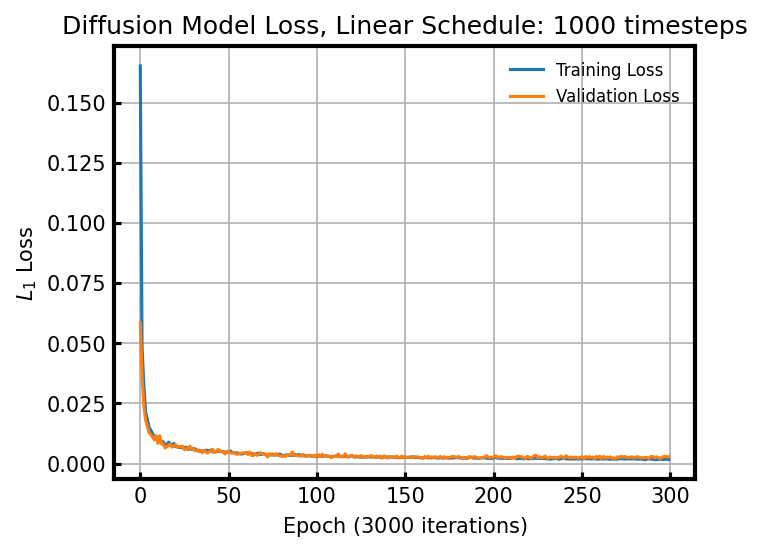

<Figure size 640x480 with 0 Axes>

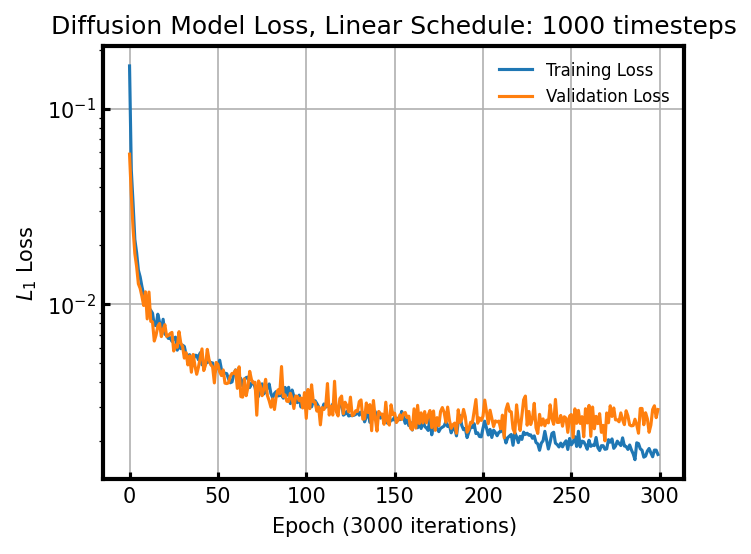

In [8]:

test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'validation_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Validation Loss')
plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()
plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.savefig(os.path.join(analysis_folder, 'diff_loss_linear_scale.png'))
plt.show()
plt.clf()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)
plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Validation Loss')
plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()
plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')

plt.grid(which = 'major')
frame_tick()
plt.yscale('log')
plt.savefig(os.path.join(analysis_folder, 'diff_loss_log_scale.png'))
plt.show()
plt.clf()
plt.close('all')

### Defining simulation object for plotting loss curves

In [9]:
class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'validation_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss


### Demonstration: Plotting loss curves 

In [10]:
if encoding == 'True':
    test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
    train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

    plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

    plt.plot(train_loss[:], label = 'Training Loss')
    plt.plot(test_loss, label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()
    plt.title('Encoder Model Loss')
    plt.grid(which = 'major')
    frame_tick()
    plt.savefig(os.path.join(analysis_folder, 'encoder_loss_linear_scale.png'))
    plt.clf()

True

### Initialize encoder and diffusion models

In [18]:
from runners.train_diffusion import DiffusionModel

def initialize_diffusion(diff_dir, enc_dir, datasets, timesteps, conditioning, encoding, schedule, device):
    ''' 
    Parameters:
        diff_dir: (str) Diffusion results directory
        enc_dir: (str) Encoder results directory
        datasets: (tuple or list) The three dataset objects corresponding to the train/validation/test splits, in the order (train, validation, test).
        timesteps: (int) The number of timesteps used for the diffusion model during training
        conditioning: (boolean) If true, the diffusion model assumes the LR passes through an encoder before being used for conditioning
        schedule: (str) Variance schedule used for training the diffusion model
        device: (str) 'cuda' for GPU, 'cpu' for CPU.
    Returns:
        diffusion_model: Custom DiffusionModel object that enables sampling with either DDIM or DDPM samplers.
    '''
    encoding_flag = encoding  == 'True'
    diffusion_model = DiffusionModel(results_folder=diff_dir,
                                    lr_encoder_folder=enc_dir,
                                    train_dataset=datasets[0],
                                    dev_dataset=datasets[1],
                                    test_dataset=datasets[2],
                                    timesteps=timesteps,
                                    conditioning=conditioning,
                                    encoding=encoding_flag,
                                    schedule=schedule,
                                    device=device,
                                    )
    diffusion_model.load_saved_model()
    return diffusion_model

diff_model = initialize_diffusion(diff_dir=diffusion_results_dir,
                                  enc_dir=encoder_results_dir,
                                  datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                  timesteps=timesteps,
                                  conditioning=conditioning,
                                  encoding=encoding,
                                  schedule=schedule,
                                  device=device)

if encoding == 'True':

    lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
else:
    lr_enc = None


not loading encoder, ..., encoding = False 
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitupscaled/2023_02_14_20_37_17/standardize/n_steps_1
model found, loading


### Define diffusion prediction function
Note: This may eventually be moved to analysis_functions.py, but is provided here to allow for easier editing/debugging

In [20]:
def predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dataset, skip = 50):

    '''
    Return the predictions for the Diffusion model given an input batch
    Parameters:
    diff_model: DiffusionModel object
    lr_enc: Torch network module object, representing the trained RRDN encoder model
    res: Torch tensor, Residual between HR and LR data
    hr: Torch tensor, High Resolution data
    lr: Torch tensor, Low Resolution data
    upscaled_lr: Torch tensor, Bicubic upscaled low resolution data
    dataset: Dataset object, used for rescaling data
    Returns:
    Low resolution data, scaled to original space, 4-D numpy array (batch, channels, height, width)
    Output (Super-resolution), scaled to original space, 4-D numpy array
    High resolution data, scaled to original space, 4-D numpy array 
    '''

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)

    if diff_model.encoding:
        if len(lr.shape) < 4:

            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
            x_e = forwardpass(lr_enc, lr.to(device).float())
    else:
        x_e = upscaled_lr.to(diff_model.device).float().repeat(1,1,1, 1)
    all_images = diff_model.batch_sample(dataset = train_dataset, batch = hr, x_e = x_e, sampler = 'DDIM', skip= skip)                
    result = dataset.unscale_data(all_images.cpu().numpy()[-1, 0], input_type = 'residual') + dataset.unscale_data(upscaled_lr.numpy(), input_type = 'upscaled_lr')
        
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')

for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(train_dataloader):            
    input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
    break


Saving


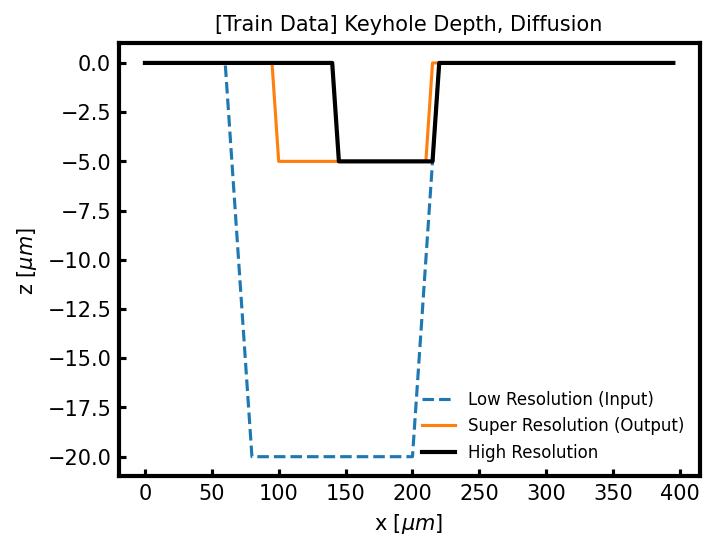

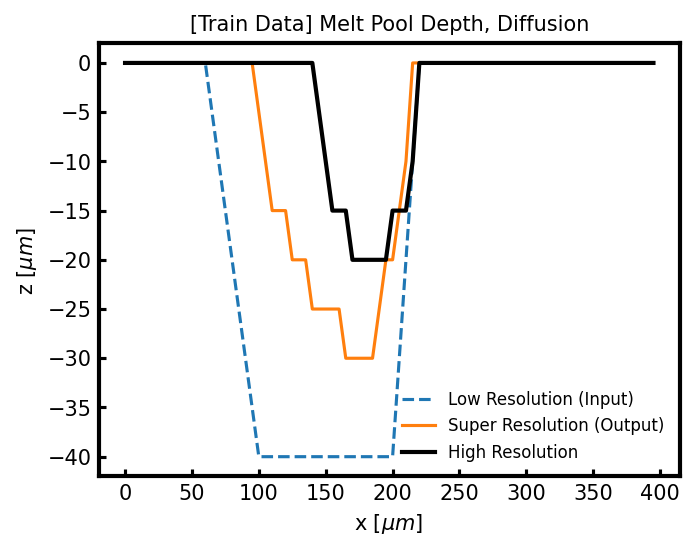

In [21]:
if encoding == 'True':

    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
split = 'Train'
kpfname = os.path.join(analysis_folder, f'diffusion_contour_line_{split}_plot_kp.png')
mpfname = os.path.join(analysis_folder, f'diffusion_contour_line_{split}_plot_mp.png')
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion", save = True, kpfname = kpfname, mpfname = mpfname )
# plt.savefig(os.path.join(analysis_folder, 'diffusion_train_contour_plot'))

kp_fname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_kp.png')
mpfname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_mp.png')
if encoding == 'True':

    plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder", save = True, kpfname = kpfname, mpfname = mpfname)
# plt.savefig(os.path.join(analysis_folder, 'encoder_train_contour_plot.png'))

if encoding == 'True':

    plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder", save = True, title = os.path.join(analysis_folder, 'encoder_train_image_plot'))
# plt.savefig()

plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion", save = True, title = os.path.join(analysis_folder, 'diffusion_train_image_plot') )


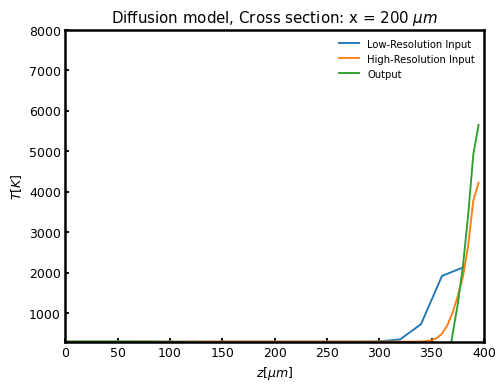

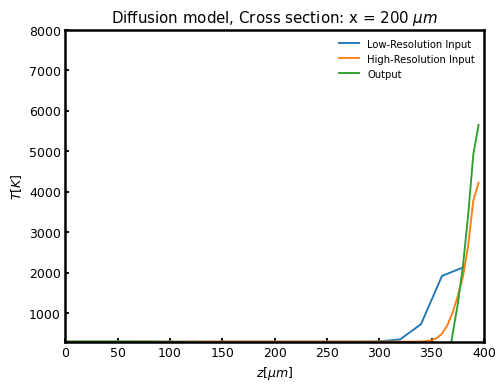

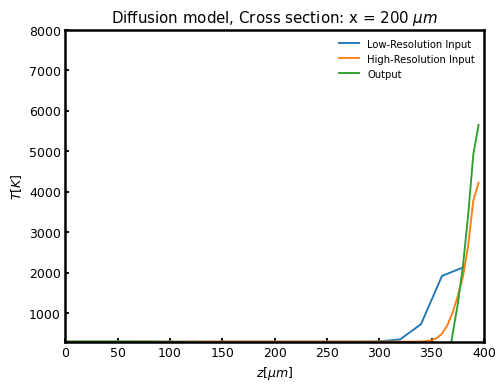

In [24]:
#### Plot temperature contours
for split, dataloader in zip(['Train', 'Validation', 'Test'], [train_dataloader, dev_dataloader, test_dataloader]):

    
    fname = os.path.join(analysis_folder, f'diffusion_temperature_line_{split}_plot_kp.png')
    plot_temp_lines(input[0,0], result_diffusion[0,0], target[0][0], split = split, modeltype = "Diffusion", save = True,fname =fname)
    # plt.savefig()
    if encoding == 'True':
        fname = os.path.join(analysis_folder, f'encoder_temperature_line_{split}_plot_mp.png')

        input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dataloader.dataset)
        plot_temp_lines(input[0,0], lr_enc_result[0][0], target[0][0], split = split, modeltype = "Encoder", save = True,fname =fname)
    # plt.savefig(os.path.join(analysis_folder, f'encoder_temperature_line_{split}_plot.png'))


##### Plot melt pool images in the validation dataset. Save figures in order of power, velocity, and time.

In [27]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image
verbose= False # controls how much information to print 
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(dev_dataloader):  
    for skips in [1]:
        oldtime = time.time()
        if verbose:
            print(res.shape)
        if encoding == 'True':
            input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
        input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
        info = info[0]
        time_elapsed = time.time()-oldtime
        if verbose:
            print(info)
        if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                timestep = 0
        else:
            timestep += 1
        folder = os.path.join(analysis_folder, 'time_stepped/'  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()))

        os.makedirs(folder,exist_ok = True)
        title  = os.path.join(folder, 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
        if verbose:
            print(title, timestep)
        plot_images(input[0], result_diffusion[0], target[0][0], timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, save = True, title =  title)
        if verbose:
            print(time_elapsed, "elapsed time")
        last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    if batch_idx > 4:
        break


#### Calculate melt pool dimensions in the validation dataset, order the results in terms of processing conditions

In [28]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image
enc_depths_sim = []
diff_depths_sim = []
gt_depths_sim = []

enc_kp_sim = []
diff_kp_sim = []
gt_kp_sim = []
gt_results = {}
enc_results = {}
diff_results = {}
skip = 50
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(dev_dataloader), total = len(dev_dataloader)):  
   

    oldtime = time.time()
    if encoding == 'True':

        input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
    info = info[0] # info is technically returned with an extra dimension, this command removes it.
    time_elapsed = time.time()-oldtime

    if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
        timestep = 0

        enc_depths_sim = []
        diff_depths_sim = []
        gt_depths_sim = []

        enc_kp_sim = []
        diff_kp_sim = []
        gt_kp_sim = []

    else:
        timestep += 1
    profile_diff, kp_diff = get_profile(result_diffusion[0])
    profile_gt, kp_gt = get_profile(target[0])
    if encoding == 'True':
    
        profile_enc, kp_enc = get_profile(result[0])

    if encoding == 'True':

        enc_kp_sim.append(5*(80-np.min(kp_enc)))
    gt_kp_sim.append(5*(80-np.min(kp_gt)))
    diff_kp_sim.append(5*(80-np.min(kp_diff)))
    if encoding == 'True':

        enc_depths_sim.append(5*(80-np.min(profile_enc)))
    gt_depths_sim.append(5*(80-np.min(profile_gt)))
    diff_depths_sim.append(5*(80-np.min(profile_diff)))

    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
    if encoding == 'True':
    
        enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
    diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_kp_sim
    gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
    if encoding == 'True':
        enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
    diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_depths_sim
    if batch_idx > 3:
        break
        # break

  0%|          | 4/4059 [00:01<32:19,  2.09it/s]


In [29]:
import pandas as pd
os.makedirs(os.path.join(analysis_folder, 'csv_files'), exist_ok = True)
pd.DataFrame.from_dict(gt_results).to_csv(os.path.join(analysis_folder, 'csv_files/gt_results.csv'))
if encoding == 'True':

    pd.DataFrame.from_dict(enc_results).to_csv(os.path.join(analysis_folder, 'csv_files/enc_results.csv'))
pd.DataFrame.from_dict(diff_results).to_csv(os.path.join(analysis_folder, 'csv_files/diff_results.csv'))


##### Plot keyhole and melt pool depths over time for each power/velocity combination

In [30]:
depth_folder = os.path.join(analysis_folder, 'depth_over_time')
os.makedirs(depth_folder, exist_ok = True)
for key in enc_results.keys():
    if encoding == 'True':  
        plt.plot(enc_results[key], label = 'Encoder Model Output')
    plt.plot(diff_results[key], label = 'Diffusion Model Output')
    plt.plot(gt_results[key], label = 'Ground Truth')
    power_text = key.split('power')[1].split('vel')[0]
    vel_text = key.split('vel')[1]
    plt.title(f'Power: {power_text} W , Velocity: {vel_text} mm/s')
    frame_tick()
    plt.legend()
    
    plt.savefig(os.path.join(depth_folder, f'{key}.png'))
    plt.clf()
    # plt.show()

#### Calculate melt pool/keyhole dimensions for DDIM sampler for varying number of timesteps

In [31]:
run_skip_ablation = False
if run_skip_ablation:
    max_depth_gt = []
    max_depth_input = []
    kp_depth_gt = []
    kp_depth_input = []
    kp_depth_diffs = []
    max_depth_diffs = []
    psnrs_lr = []
    psnrs_diff= []

    ssims_diff = []
    ssims_lr = []

    l1_lr = []
    l1_diff = []

    sample_times = []
    steps_list= []
    psnr_mean_lr = []
    ssim_mean_lr = []
    l1_mean_lr = []
    ssim_mean_diff = []
    psnr_mean_diff = []
    l1_mean_diff = []
    l1loss = nn.L1Loss()
    factor = 2
    mesh_hr = 5
    mesh_lr = 20

    for skips in [1, 2, 3, 5, 10, 15, 20, 50]:
        diff_steps = diff_model.timesteps
        kp_depth_diff = []
        max_depth_diff = []
        max_depth_input= []
        kp_depth_input = []
        max_depth_gt  = []
        kp_depth_gt = []
        psnr_batches_lr = []
        psnr_batches_diff = []
        l1_batches_diff = []
        l1_batches_lr = []
        ssim_batches_lr = []
        ssim_batches_diff = []

        for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(dev_dataloader):  
            oldtime = time.time()
            input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
            upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
            lrpsnr = PSNR(upscale, target, target.shape[0]).item()

            diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
            psnr_batches_diff.append(diffpsnr)
            psnr_batches_lr.append((lrpsnr))
            lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
            diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
            lrl1 = l1loss(upscale, target)
            diffl1 = l1loss(torch.tensor(result_diffusion), target)
            ssim_batches_lr.append(lrssim)
            ssim_batches_diff.append(diffssim)
            l1_batches_lr.append(lrl1)
            l1_batches_diff.append(diffl1)
            for i, rd in enumerate(result_diffusion):
                elapsed = time.time() - oldtime
                if batch_idx == 0:
                    sample_times.append(elapsed)
                    steps_list.append(timesteps//skips)
                profile_diff, kp_diff = get_profile(result_diffusion[i])
                profile_gt, kp_gt = get_profile(target[i])
                profile_input, kp_input = get_profile(input[i], mesh = 20)

                max_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
                max_depth_diff.append(mesh_hr*(20*factor-5*factor  -np.min(profile_diff)))
                max_depth_input.append(mesh_lr*(20-5- np.min(profile_input)))
                kp_depth_gt.append(mesh_hr*(20*factor-5*factor-np.min(kp_gt)))
                kp_depth_input.append(mesh_lr*(20-5-np.min(kp_input)))
                kp_depth_diff.append(mesh_hr*(20*factor-5*factor-np.min(kp_diff)))
                
        kp_depth_diffs.append(kp_depth_diff)
        max_depth_diffs.append(max_depth_diff)
        ssims_diff.append(ssim_batches_diff)
        ssims_lr.append(ssim_batches_lr)
        l1_lr.append(l1_batches_lr)
        psnrs_lr.append(psnr_batches_lr)
        psnrs_diff.append(psnr_batches_diff)
        l1_diff.append(l1_batches_diff)
        psnr_mean_lr.append(np.mean(psnr_batches_lr))
        psnr_mean_diff.append(np.mean(psnr_batches_diff))
        ssim_mean_diff.append(np.mean(ssim_batches_diff))
        ssim_mean_lr.append(np.mean(ssim_batches_lr))
        l1_mean_lr.append(np.mean(l1_batches_lr))
        l1_mean_diff.append(np.mean(l1_batches_diff))
        

### Calculate melt pool and keyhole dimensions

In [32]:
def get_inst_profile(image, mesh = 5):
    image = image[0].T
    print(image.shape)
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

#### Plot melt pool statistics

In [33]:
import sklearn
from sklearn.metrics import mean_absolute_error
if run_skip_ablation:
    plt.figure(figsize = [4,3], dpi = 150)
    plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
    plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
    maes_depth = []
    for max_depth, skips in zip(max_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
        plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    
        mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
        mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
        maes_depth.append(mae_depth_diff)
        print(mae_depth_diff, max_depth)
        
        plt.xlim(0,300)
        plt.ylim(0,300)
        frame_tick()
    plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
    plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
    plt.title('Validation Set')
    plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
    plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
    plt.legend(fontsize = 5, loc = 'lower right')
    plt.show()

#### Plot keyhole statistics

In [34]:
import sklearn
from sklearn.metrics import mean_absolute_error
if run_skip_ablation:

    plt.figure(figsize = [4,3], dpi = 150)
    plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
    plt.scatter(max_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
    maes_depth = []
    for kp_depth, skips in zip(kp_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
        plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    
        mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
        mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
        maes_depth.append(mae_depth_diff)
    
        plt.xlim(0,300)
        plt.ylim(0,300)
        frame_tick()
        print(maes_depth)
        
    plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
    plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
    plt.title('Validation Set')
    plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
    plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
    plt.legend(fontsize = 5, loc = 'lower right')
    plt.show()

In [35]:
if run_skip_ablation:

    plt.plot(steps_list[::12], maes_depth, '.')
    frame_tick()
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
    plt.show()
    frame_tick()

    plt.plot(steps_list[::12], sample_times[::12], '.')
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'Elapsed Time (s)')
    plt.show()


    plt.plot(steps_list[::12], maes_depth, '.')
    frame_tick()
    plt.xlabel('Sampling Timesteps')
    plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
    plt.show()
    frame_tick()


#### Calculate the melt pool/keyhole dimensions for a single value of DDIM sampling timesteps

In [36]:
max_depth_gt = []
max_depth_input = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
sample_times = []
steps_list= []
skip  = 500
mesh_hr = 5
factor =4 
mesh_lr = 20
kp_depth_diff = []
max_depth_diff = []
max_depth_input= []
kp_depth_input = []
max_depth_gt  = []
kp_depth_gt = []
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(dev_dataloader), total = len(dev_dataloader)):  
    oldtime = time.time()
    input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset, skip = skip)
    for i, rd in enumerate(result_diffusion):
        elapsed = time.time() - oldtime
        if batch_idx == 0:
            sample_times.append(elapsed)
            steps_list.append(timesteps//skips)
        profile_diff, kp_diff = get_profile(result_diffusion[i])
        profile_gt, kp_gt = get_profile(target[i])
        profile_input, kp_input = get_profile(input[i], mesh = 20)
      
        max_depth_gt.append(mesh_hr*(20*factor - np.min(profile_gt)))
        max_depth_diff.append(mesh_hr*(20*factor  -np.min(profile_diff)))
        max_depth_input.append(mesh_lr*(20 - np.min(profile_input)))
        kp_depth_gt.append(mesh_hr*(20*factor-np.min(kp_gt)))
        kp_depth_input.append(mesh_lr*(20-np.min(kp_input)))
        kp_depth_diff.append(mesh_hr*(20*factor-np.min(kp_diff)))
    if batch_idx > 4:
        break
 
kp_depth_diffs.append(kp_depth_diff)
max_depth_diffs.append(max_depth_diff)

print(kp_depth_diffs)

  0%|          | 5/4059 [00:00<03:49, 17.69it/s]

[[0, 0, 5, 5, 5, 5]]


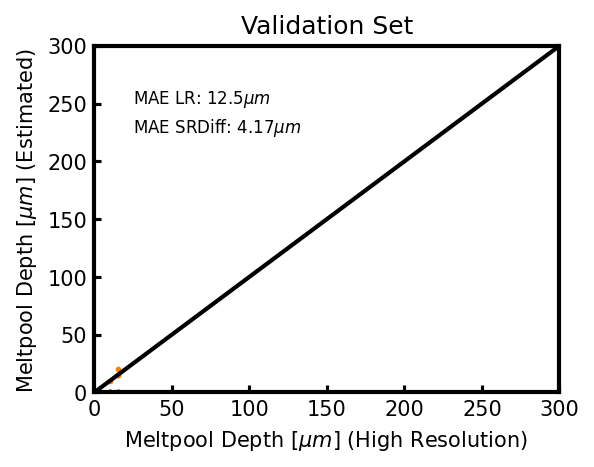

In [37]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth_diff, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth_diff)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Meltpool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Meltpool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.savefig(os.path.join(analysis_folder, 'melt_pool_depth_validation_gridsearch.png'))
plt.show()

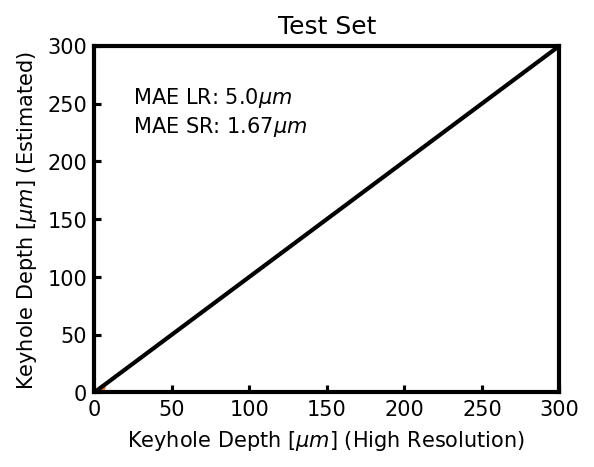

In [38]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_diff)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.savefig(os.path.join(analysis_folder, 'keyhole_depth_test_gridsearch.png'))

plt.show()